In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
%run ../ODE/lib.ipynb

In [3]:
from scipy.integrate import solve_ivp
#timestep adattivo

In [4]:
m1 = 0.5
m2 = 0.5
a = 20

In [5]:
# l'integrazione andrà stoppata prima che la descrizione newtoniana fallisca
# per farlo possiamo definire un evento (es. raggiungimento isco) che termina l'integrazione

Part 1: Equations of Motion
The equations of motion for body 1 including Newtonian gravity and the 2.5 PN radiation reaction term are (from here, eq. 339):

$$
\begin{align*}
\boldsymbol{a}_1= & -\frac{G m_2}{r_{12}^2} \boldsymbol{n}_{12} \\
+ & \frac{1}{c^5}\left\{\left[\frac{208 G^3 m_1 m_2^2}{15 r_{12}^4}\left(n_{12} v_{12}\right)-\frac{24 G^3 m_1^2 m_2}{5 r_{12}^4}\left(n_{12} v_{12}\right)+\frac{12 G^2 m_1 m_2}{5 r_{12}^3}\left(n_{12} v_{12}\right) v_{12}^2\right] \boldsymbol{n}_{12}\right. \\
& \left.\quad+\left[\frac{8 G^3 m_1^2 m_2}{5 r_{12}^4}-\frac{32 G^3 m_1 m_2^2}{5 r_{12}^4}-\frac{4 G^2 m_1 m_2}{5 r_{12}^3} v_{12}^2\right] \boldsymbol{v}_{12}\right\} \tag{1}
\end{align*}
$$



The equations for body 2 are obtained by the exchange $1 \leftrightarrow 2$, remembering that $\boldsymbol{n}_{12}$ and $\boldsymbol{v}_{12}$ change sign under this operation ( $\boldsymbol{n}_{21}=-\boldsymbol{n}_{12}$ ).
1. Consider adequate internal units, e.g. when $G=c=M=1$.
2. Reduce both equations of motion to a system of first-order ODEs for the state vector $\left(\boldsymbol{r}_1, \boldsymbol{r}_2, \boldsymbol{v}_1, \boldsymbol{v}_2\right)$ and integrate them numerically using a method of your choice (e.g. RungeKutta 4). Choose initial conditions corresponding to a quasi-circular orbit with a given semi-major axis $a_0$ and eccentricity $e_0$.
3. At each time step, compute the instantaneous orbital elements $a(t)$ and $e(t)$ from the relative coordinate $\boldsymbol{r}=\boldsymbol{r}_1-\boldsymbol{r}_2$ and relative velocity $\boldsymbol{v}=\boldsymbol{v}_1-\boldsymbol{v}_2$, using:

$$
\begin{align*}
& \mathcal{E}=\frac{v^2}{2}-\frac{G M}{r}, \quad a=-\frac{G M}{2 \mathcal{E}},  \tag{2}\\
& \boldsymbol{h}=\boldsymbol{r} \times \boldsymbol{v}, \quad e=\sqrt{1-\frac{h^2}{G M a}}, \tag{3}
\end{align*}
$$

where $M=m_1+m_2, r=|\boldsymbol{r}|, v=|\boldsymbol{v}|, h=|\boldsymbol{h}|$.


4. Be aware that you cannot integrate down to the merger, so you need to set a max time (i.e. the time to merger, see below), or enforce a check on the value of the separation vector (i.e. $r>6$, using appropriate units).

In [6]:
#ignoriamo i termini conservativi in 1/c^3 1/c^4

In [7]:
G = 1
c = 1
M = 1

In [8]:
def unpack(y):
    r1 = np.array([y[0],y[2],y[4]])
    v1 = np.array([y[1],y[3],y[5]])
    r2 = np.array([y[6],y[8],y[10]])
    v2 = np.array([y[7],y[9],y[11]])
    return r1,v1,r2,v2

In [9]:
def f_prime(t, y):
    
    r1 = np.array([y[0],y[2],y[4]])
    v1 = np.array([y[1],y[3],y[5]])
    r2 = np.array([y[6],y[8],y[10]])
    v2 = np.array([y[7],y[9],y[11]])
    
    vec_r12 = r1-r2
    r12 = np.sqrt(np.dot(vec_r12,vec_r12))
    n12 = vec_r12/r12

    vec_v12 = v1-v2
    v12 = np.sqrt(np.dot(vec_v12,vec_v12))
    
    
    a1 = ( -G*m2/r12**2* n12 
          + 1/c**5 * ( ( 208*G**3*m1*m2**2/(15*r12**4)*np.dot(n12,vec_v12) - 24*G**3*m1**2*m2/(5*r12**4)*np.dot(n12,vec_v12) + 12*G**2*m1*m2/(5*r12**3)*np.dot(n12,vec_v12)*v12**2 ) * n12
                   + ( 8*G**3*m1**2*m2/(5*r12**4) - 32*G**3*m1*m2**2/(5*r12**4) - 4*G**2*m1*m2/(5*r12**3)*v12**2 ) * vec_v12 ) ) 
         
    a2 = ( -G*m2/r12**2* (-n12)
          + 1/c**5 * ( ( 208*G**3*m1*m2**2/(15*r12**4)*np.dot(-n12,-vec_v12) - 24*G**3*m1**2*m2/(5*r12**4)*np.dot(-n12,-vec_v12) + 12*G**2*m1*m2/(5*r12**3)*np.dot(-n12,-vec_v12)*v12**2 ) * (-n12)
                    + ( 8*G**3*m1**2*m2/(5*r12**4) - 32*G**3*m1*m2**2/(5*r12**4) - 4*G**2*m1*m2/(5*r12**3)*v12**2 ) * (-vec_v12) ) ) 
         
    return v1[0], a1[0], v1[1], a1[1], v1[2], a1[2], v2[0], a2[0], v2[1], a2[1], v2[2], a2[2]

In [10]:
def stop_merger(t, y, r_min=6):
    r1,v1,r2,v2 = unpack(y)
    return np.linalg.norm(r1 - r2) - r_min

def t_merger_circ(a0):
    beta = 64/5*G**3*m1*m2*M/c**5
    return a0**4/(4*beta)

In [11]:
h = 0.01
tf = 25000

t_span =  [0,tf]
e = 0.
vy_01 = -m2/M * np.sqrt(G*M/a*(e+1)/(-e+1))
vy_02 = +m1/M * np.sqrt(G*M/a*(e+1)/(-e+1))
y0 = [-a*(1-e)/2,0,0,vy_01,0,0,a*(1-e)/2,0,0,vy_02,0,0]

In [12]:
t_ev = np.linspace(0,t_merger_circ(a),int(1e4))

sol = solve_ivp(f_prime, t_span, y0, t_eval=t_ev,events=stop_merger, rtol=1e-10, atol=1e-10)

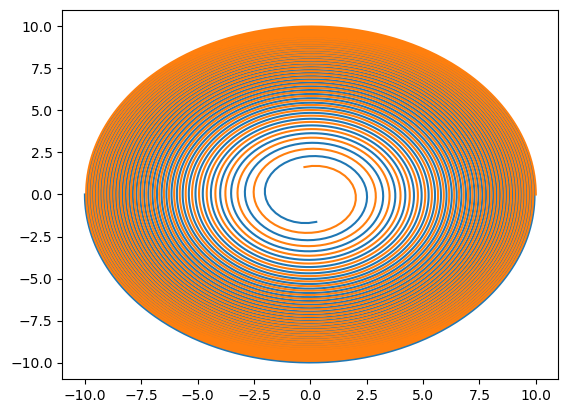

In [13]:
plt.plot(sol['y'][0], sol['y'][2])
plt.plot(sol['y'][6], sol['y'][8])

In [14]:
def eps(y):
    '''
    r1,v1,r2,v2 = unpack(y)
    v = v1 - v2
    r = r1 - r2
    v_norm = []
    r_norm = []
    
    for i in range(len(r[0,:])):
        v_norm.append(np.linalg.norm(v[:,i])) 
        r_norm.append(np.linalg.norm(r[:,i]))
    v_norm = np.array(v_norm)
    r_norm = np.array(r_norm)
    '''
    r = np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2)
    v = np.sqrt((y[1]-y[7])**2+(y[3]-y[9])**2+(y[5]-y[11])**2)
    
    return v**2/2 - G*M/r

In [15]:
def a_t(y):
    return - G*M/(2*eps(y))

def e_t(y):
    r1,v1,r2,v2 = unpack(y)
    r = r1-r2
    v = v1-v2
    print(v[0,:].shape)
    h_t = []
    for i in range(len(v[0,:])):
        h_t.append(np.cross(r[:,i],v[:,i]))
        
    h_t = np.array(h_t)
    print(h_t[:,0].shape)

    e = []
    for i in range(len(v[0,:])):
        e.append(np.sqrt(1 - np.linalg.norm(h_t[i,:])**2 / (G*M*a_t(y[:,i]))))
    return e

def f(e):
    return (1 + 73/24*e**2 + 37/96*e**4)/(1 - e**2)**(7/2)

def g(e):
    return (1 + 121/304*e**2)/(1 - e**2)**(5/2)

def ae_prime(t,y):
    a,e = y
    dadt = -64/5*G**3*m1*m2*M/(c**5*a**3) * f(e)
    dedt = -304/15*e*G**3*m1*m2*M/(c**5*a**4) * g(e)

    return dadt, dedt

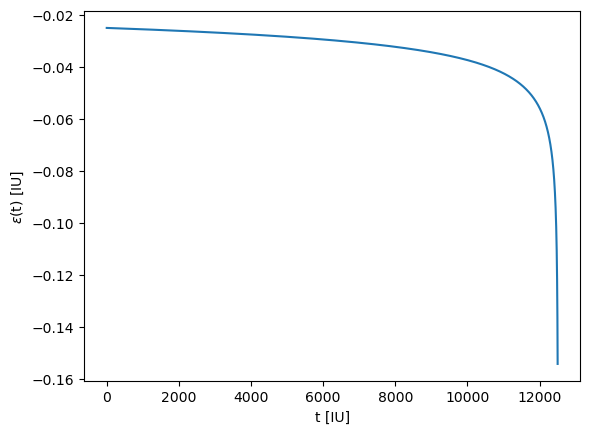

In [16]:
plt.plot(sol['t'],eps(sol['y']))
plt.xlabel('t [IU]')
plt.ylabel(r'$\epsilon$(t) [IU]');

In [17]:
y0_ae = [a,e]

sol_ae_theo = solve_ivp(ae_prime, t_span, y0_ae, t_eval=t_ev)

In [18]:
sol_ae_theo['y'][1].shape

(10000,)

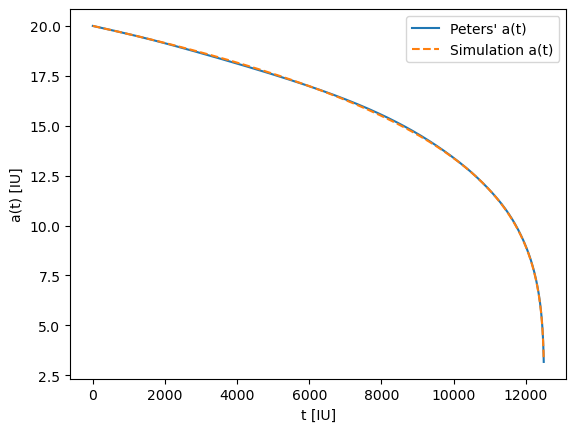

In [19]:
plt.plot(sol_ae_theo['t'],(sol_ae_theo['y'][0]),label='Peters\' a(t)')
plt.plot(sol['t'],a_t(sol['y']),label='Simulation a(t)',linestyle='--')
plt.xlabel('t [IU]')
plt.ylabel(r'a(t) [IU]')
plt.legend();

In [20]:
ind_merg = np.argmin(a_t(sol['y']))
print('computed merger time: %.2f' % sol['t'][ind_merg])
print('predicted merger time: %.2f' % t_merger_circ(a))

computed merger time: 12500.00
predicted merger time: 12500.00


(10000,)
(10000,)


/tmp/ipykernel_150316/3309235267.py:18: RuntimeWarning: invalid value encountered in sqrt
  e.append(np.sqrt(1 - np.linalg.norm(h_t[i,:])**2 / (G*M*a_t(y[:,i]))))


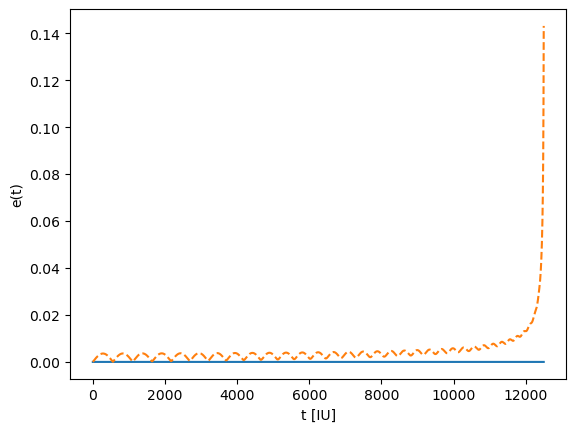

In [21]:
plt.plot(sol_ae_theo['t'],(sol_ae_theo['y'][1]),label='Peters\' e(t)')
plt.plot(sol['t'],e_t(sol['y']),label='Simulation e(t)',linestyle='--')
plt.xlabel('t [IU]')
plt.ylabel(r'e(t)');

Part 3:
-

In [29]:
def ddI(t, y):
    r1, v1, r2, v2 = unpack(y)
    v10, a1, v20, a2 = unpack(f_prime(t,y))
    
    ddI = []
    for i in range(3):
        ddI_i = []
        for j in range(3):
            ddI_ij = m1*(a1[i]*r1[j] + 2*v1[i]*v1[j] + r1[i]*a1[j]) + m2*(a2[i]*r2[j] + 2*v2[i]*v2[j] + r2[i]*a2[j])
            ddI_i.append(ddI_ij) 
        ddI.append(ddI_i)
        
    return np.array(ddI)
def P(n):
    P = []
    for i in range(3):
        P_i = []
        for j in range(3):
            if i==j: P_ij = 1 - n[i]*n[j]
            P_i.append(P_ij)
        P.append(P_i)
    return np.array(P)
    
def Lambda(n):
    L = np.zeros((3,3,3,3))
    
    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    L[i,j,k,l] = P(n)[i,k]*P(n)[j,l] - 0.5*P(n)[i,j]*P(n)[k,l]
    return (L).T

def hTT(t,y,R=1000):
    r1, v1, r2, v2 = unpack(y)
    r = r1-r2
    n = r/R
    
    h = np.zeros((3,3))
    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    h[i,j] += 2*G/(c**4*R) * Lambda(n)[i,j,k,l]*ddI(t-R/c,y)[k,l]
    return (h).T

In [30]:
I_dot_dot = []
L = []
for it in range(len(sol['t'])):
    I_dot_dot.append(ddI(sol['t'][it],sol['y'][:,it]))
I_dot_dot = np.array(I_dot_dot)
I_dot_dot.shape

(10000, 3, 3)

In [31]:
#np.outer
#np.einsum

In [34]:
h = []
for it in range(len(sol['t'])):
    h.append(hTT(sol['t'][it],sol['y'][:,it]))



In [35]:
h

[array([[-3.23387948e-08, -1.23557355e-08, -1.23557355e-08],
        [-1.23557355e-08,  7.64026450e-09,  7.64026450e-09],
        [-1.23507948e-08,  7.64026450e-09,  7.64026450e-09]]),
 array([[-1.42931123e-06, -1.40990308e-06, -1.40990308e-06],
        [-1.40990308e-06, -1.38992320e-06, -1.38992320e-06],
        [-1.40933934e-06, -1.38992320e-06, -1.38992309e-06]]),
 array([[-2.82512588e-06, -2.80632205e-06, -2.80632205e-06],
        [-2.80632205e-06, -2.78638948e-06, -2.78638948e-06],
        [-2.80520128e-06, -2.78638948e-06, -2.78638861e-06]]),
 array([[-4.21869398e-06, -4.20052198e-06, -4.20052198e-06],
        [-4.20052198e-06, -4.18066777e-06, -4.18066777e-06],
        [-4.19884768e-06, -4.18066777e-06, -4.18066481e-06]]),
 array([[-5.60892860e-06, -5.59141398e-06, -5.59141398e-06],
        [-5.59141398e-06, -5.57166892e-06, -5.57166892e-06],
        [-5.58919138e-06, -5.57166892e-06, -5.57166193e-06]]),
 array([[-6.99474553e-06, -6.97791178e-06, -6.97791178e-06],
        [-6.97

In [38]:
h = np.array(h)

(10000, 3, 3)